# The MOT Dataset

Here we explore the MOT 20 Dataset focussing on data disintegreties anomalies and suitability for our training purposes, we also discuss what derived features can be applied in this situation and we also export the actual training set.

Nick Grebe - i6377605

## IF THIS IS YOUR FIRST TIME RUNNING:


1. add the dataset like this:

![MOT dataset structure](MOT-DS-STRUCT.png)

2. run the MOT_loader.py main
3. Start this Notebook

In [1]:
from __future__ import annotations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Dataprep":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Dataprep import MOT_loader as mot

In [2]:
project_root = PROJECT_ROOT
mot_source = project_root / "Dataprep" / "MOTsource"

frame_df, ann_df = mot.build_mot_tables(
    mot_source_dir=mot_source,
    include_empty_frames=False,
    include_gt=True,
    include_det=True,
)
#Impelemted the Train test split recommended by MOT + additonal val:
# train: 01,02,02
#val: 05
#test: 04,06,07,08
# for specifics check the MOT Loader
splits = mot.split_mot_tables(frame_df, ann_df)

train_frame_df = splits["train_frame"]
val_frame_df = splits["val_frame"]
test_frame_df = splits["test_frame"]

train_ann_df = splits["train_ann"]
val_ann_df = splits["val_ann"]
test_ann_df = splits["test_ann"]

In [3]:
print(train_frame_df["sequence"].drop_duplicates().tolist())
print(val_frame_df["sequence"].drop_duplicates().tolist())
print(test_frame_df["sequence"].drop_duplicates().tolist())

print(train_frame_df.shape)
print(val_frame_df.shape)
print(test_frame_df.shape)


print(train_ann_df.shape)
print(val_ann_df.shape)
print(test_ann_df.shape)


['MOT20-01', 'MOT20-02', 'MOT20-03']
['MOT20-05']
['MOT20-04', 'MOT20-06', 'MOT20-07', 'MOT20-08']
(5616, 10)
(3315, 10)
(4479, 10)
(865384, 24)
(1132679, 24)
(361798, 24)


## Exploratory Data anal

In [4]:
def summarize_split(frame_df: pd.DataFrame, ann_df: pd.DataFrame, split_name: str) -> None:
    print(f"{split_name.upper()}")
    print("frames:", len(frame_df))
    print("annotations:", len(ann_df))
    print("sequences:", ann_df["sequence"].nunique())
    print("unique track ids (within-sequence identities):", ann_df[["sequence", "track_id"]].drop_duplicates().shape[0])
    print("avg annotations per frame:", round(len(ann_df) / len(frame_df), 2) if len(frame_df) else 0)
    print()


for split_name, frame_part, ann_part in [
    ("train", train_frame_df, train_ann_df),
    ("val", val_frame_df, val_ann_df),
    ("test", test_frame_df, test_ann_df),
]:
    summarize_split(frame_part, ann_part, split_name)

def build_track_table(ann_df: pd.DataFrame) -> pd.DataFrame:
    gt = ann_df[ann_df["source"] == "gt"].copy()

    track_df = (
        gt.groupby(["dataset", "split", "sequence", "track_id"], as_index=False)
        .agg(
            start_frame=("frame_id", "min"),
            end_frame=("frame_id", "max"),
            num_annotations=("frame_id", "size"),
            mean_visibility=("visibility", "mean"),
            min_visibility=("visibility", "min"),
            mean_bbox_area=("bbox_area", "mean"),
            mean_w=("w", "mean"),
            mean_h=("h", "mean"),
        )
    )

    track_df["frame_span"] = track_df["end_frame"] - track_df["start_frame"] + 1
    track_df["missing_frames_inside_span"] = track_df["frame_span"] - track_df["num_annotations"]
    track_df["coverage_ratio"] = track_df["num_annotations"] / track_df["frame_span"]

    return track_df.sort_values(
        ["split", "sequence", "track_id"]
    ).reset_index(drop=True)


track_df = build_track_table(ann_df)
track_df.head()

TRAIN
frames: 5616
annotations: 865384
sequences: 3
unique track ids (within-sequence identities): 1124
avg annotations per frame: 154.09

VAL
frames: 3315
annotations: 1132679
sequences: 1
unique track ids (within-sequence identities): 1212
avg annotations per frame: 341.68

TEST
frames: 4479
annotations: 361798
sequences: 4
unique track ids (within-sequence identities): 4
avg annotations per frame: 80.78



,dataset,split,sequence,track_id,start_frame,end_frame,num_annotations,mean_visibility,min_visibility,mean_bbox_area,mean_w,mean_h,frame_span,missing_frames_inside_span,coverage_ratio
0,MOT20,train,MOT20-01,1,1,338,338,0.527653,0.066033,25555.899408,108.778107,230.866864,338,0,1.0
1,MOT20,train,MOT20-01,2,1,351,351,0.672314,0.000554,22922.022792,95.792023,235.396011,351,0,1.0
2,MOT20,train,MOT20-01,3,1,367,367,0.631466,0.031469,17416.686649,82.735695,208.866485,367,0,1.0
3,MOT20,train,MOT20-01,4,1,42,42,0.882382,0.448040,23580.380952,97.857143,240.047619,42,0,1.0
4,MOT20,train,MOT20-01,5,1,249,249,0.918421,0.000000,23471.493976,116.835341,203.473896,249,0,1.0


Quick insight into the track level table

In [5]:
print("Track table shape:", track_df.shape)
print()
print("Average track length (annotations):", round(track_df["num_annotations"].mean(), 2))
print("Median track length (annotations):", round(track_df["num_annotations"].median(), 2))
print("Average frame span:", round(track_df["frame_span"].mean(), 2))
print("Average missing frames inside span:", round(track_df["missing_frames_inside_span"].mean(), 2))
print("Average coverage ratio:", round(track_df["coverage_ratio"].mean(), 4))
print()
print("Tracks per split:")
print(track_df.groupby("split").size())
print()
print("Track length summary by split:")
print(track_df.groupby("split")["num_annotations"].describe())


Track table shape: (2332, 15)

Average track length (annotations): 573.29
Median track length (annotations): 453.0
Average frame span: 573.29
Average missing frames inside span: 0.0
Average coverage ratio: 1.0

Tracks per split:
split
train    2332
dtype: int64

Track length summary by split:
        count       mean         std  min    25%    50%     75%     max
split                                                                  
train  2332.0  573.29331  586.478139  1.0  227.0  453.0  710.25  3315.0


Longest tracks and identity

In [6]:
longest_tracks = track_df.sort_values("num_annotations", ascending=False).head(20)
longest_tracks[[
    "dataset", "split", "sequence", "track_id", "num_annotations",
    "start_frame", "end_frame", "frame_span", "missing_frames_inside_span",
    "coverage_ratio", "mean_visibility"
]]


,dataset,split,sequence,track_id,num_annotations,start_frame,end_frame,frame_span,missing_frames_inside_span,coverage_ratio,mean_visibility
1956,MOT20,train,MOT20-05,836,3315,1,3315,3315,0,1.0,0.679617
2317,MOT20,train,MOT20-05,1197,3315,1,3315,3315,0,1.0,1.000000
1958,MOT20,train,MOT20-05,838,3315,1,3315,3315,0,1.0,0.750159
1964,MOT20,train,MOT20-05,844,3315,1,3315,3315,0,1.0,0.674814
1926,MOT20,train,MOT20-05,806,3315,1,3315,3315,0,1.0,0.390134
1918,MOT20,train,MOT20-05,798,3315,1,3315,3315,0,1.0,0.180069
1917,MOT20,train,MOT20-05,797,3315,1,3315,3315,0,1.0,0.492560
1919,MOT20,train,MOT20-05,799,3315,1,3315,3315,0,1.0,0.150204
1928,MOT20,train,MOT20-05,808,3315,1,3315,3315,0,1.0,0.546612
1927,MOT20,train,MOT20-05,807,3315,1,3315,3315,0,1.0,0.480543


Longest track per sequence

In [7]:
longest_per_sequence = (
    track_df.sort_values("num_annotations", ascending=False)
    .groupby(["dataset", "split", "sequence"], as_index=False)
    .first()
    .sort_values(["split", "num_annotations"], ascending=[True, False])
)

longest_per_sequence[[
    "dataset", "split", "sequence", "track_id", "num_annotations",
    "start_frame", "end_frame", "coverage_ratio", "mean_visibility"
]]


,dataset,split,sequence,track_id,num_annotations,start_frame,end_frame,coverage_ratio,mean_visibility
3,MOT20,train,MOT20-05,836,3315,1,3315,1.0,0.679617
1,MOT20,train,MOT20-02,163,2782,1,2782,1.0,1.000000
2,MOT20,train,MOT20-03,246,2405,1,2405,1.0,0.007894
0,MOT20,train,MOT20-01,80,429,1,429,1.0,1.000000


Frame density and crowding statistics

In [8]:
gt_frame_density = (
    ann_df[ann_df["source"] == "gt"]
    .groupby(["dataset", "split", "sequence", "frame_id"], as_index=False)
    .size()
    .rename(columns={"size": "gt_person_count"})
)

gt_frame_density.head()


,dataset,split,sequence,frame_id,gt_person_count
0,MOT20,train,MOT20-01,1,52
1,MOT20,train,MOT20-01,2,52
2,MOT20,train,MOT20-01,3,52
3,MOT20,train,MOT20-01,4,52
4,MOT20,train,MOT20-01,5,52


In [9]:
print("Average persons per frame by split:")
print(gt_frame_density.groupby("split")["gt_person_count"].mean())
print()
print("Max persons in a frame by split:")
print(gt_frame_density.groupby("split")["gt_person_count"].max())
print()
print("Top 20 densest frames:")
gt_frame_density.sort_values("gt_person_count", ascending=False).head(20)


Average persons per frame by split:
split
train    149.694323
Name: gt_person_count, dtype: float64

Max persons in a frame by split:
split
train    255
Name: gt_person_count, dtype: int64

Top 20 densest frames:


,dataset,split,sequence,frame_id,gt_person_count
7434,MOT20,train,MOT20-05,1819,255
7436,MOT20,train,MOT20-05,1821,255
7435,MOT20,train,MOT20-05,1820,255
7431,MOT20,train,MOT20-05,1816,254
7433,MOT20,train,MOT20-05,1818,254
7432,MOT20,train,MOT20-05,1817,254
7261,MOT20,train,MOT20-05,1646,253
7471,MOT20,train,MOT20-05,1856,253
7263,MOT20,train,MOT20-05,1648,253
7262,MOT20,train,MOT20-05,1647,253


Motion features per track

In [10]:
gt_sorted = (
    ann_df[ann_df["source"] == "gt"]
    .sort_values(["dataset", "split", "sequence", "track_id", "frame_id"])
    .copy()
)

gt_sorted["prev_frame_id"] = gt_sorted.groupby(["dataset", "split", "sequence", "track_id"])["frame_id"].shift(1)
gt_sorted["prev_foot_x"] = gt_sorted.groupby(["dataset", "split", "sequence", "track_id"])["foot_x"].shift(1)
gt_sorted["prev_foot_y"] = gt_sorted.groupby(["dataset", "split", "sequence", "track_id"])["foot_y"].shift(1)

gt_sorted["frame_gap"] = gt_sorted["frame_id"] - gt_sorted["prev_frame_id"]
gt_sorted["dx"] = gt_sorted["foot_x"] - gt_sorted["prev_foot_x"]
gt_sorted["dy"] = gt_sorted["foot_y"] - gt_sorted["prev_foot_y"]
gt_sorted["step_distance"] = (gt_sorted["dx"] ** 2 + gt_sorted["dy"] ** 2) ** 0.5

gt_sorted.head()


,dataset,split,sequence,frame_id,image_path,image_width,image_height,frame_rate,source,track_id,...,score_or_marked,class_id,visibility,prev_frame_id,prev_foot_x,prev_foot_y,frame_gap,dx,dy,step_distance
361828,MOT20,train,MOT20-01,1,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,25,gt,1,...,1.0,1,0.83643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361910,MOT20,train,MOT20-01,2,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,25,gt,1,...,1.0,1,0.84015,1.0,269.0,1081.0,1.0,2.0,-1.0,2.236068
361991,MOT20,train,MOT20-01,3,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,25,gt,1,...,1.0,1,0.84015,2.0,271.0,1080.0,1.0,2.0,0.0,2.000000
362070,MOT20,train,MOT20-01,4,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,25,gt,1,...,1.0,1,0.84015,3.0,273.0,1080.0,1.0,3.0,0.0,3.000000
362149,MOT20,train,MOT20-01,5,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,25,gt,1,...,1.0,1,0.84015,4.0,276.0,1080.0,1.0,2.0,0.0,2.000000


In [11]:
track_motion_df = (
    gt_sorted.groupby(["dataset", "split", "sequence", "track_id"], as_index=False)
    .agg(
        mean_step_distance=("step_distance", "mean"),
        max_step_distance=("step_distance", "max"),
        mean_frame_gap=("frame_gap", "mean"),
        max_frame_gap=("frame_gap", "max"),
    )
)

track_motion_df.head()


,dataset,split,sequence,track_id,mean_step_distance,max_step_distance,mean_frame_gap,max_frame_gap
0,MOT20,train,MOT20-01,1,1.930078,5.099020,1.0,1.0
1,MOT20,train,MOT20-01,2,1.796514,5.099020,1.0,1.0
2,MOT20,train,MOT20-01,3,2.465950,5.830952,1.0,1.0
3,MOT20,train,MOT20-01,4,4.616091,8.500000,1.0,1.0
4,MOT20,train,MOT20-01,5,2.137896,4.000000,1.0,1.0


Potentialy suspicious tracks

In [12]:
suspicious_tracks = track_df.merge(
    track_motion_df,
    on=["dataset", "split", "sequence", "track_id"],
    how="left",
)

suspicious_tracks = suspicious_tracks.sort_values(
    ["max_step_distance", "missing_frames_inside_span", "num_annotations"],
    ascending=[False, False, False]
)

suspicious_tracks[[
    "dataset", "split", "sequence", "track_id", "num_annotations",
    "frame_span", "missing_frames_inside_span", "coverage_ratio",
    "mean_visibility", "max_step_distance", "mean_step_distance", "max_frame_gap"
]].head(30)


,dataset,split,sequence,track_id,num_annotations,frame_span,missing_frames_inside_span,coverage_ratio,mean_visibility,max_step_distance,mean_step_distance,max_frame_gap
637,MOT20,train,MOT20-03,252,2405,2405,0,1.0,0.351456,28.935273,0.340829,1.0
1675,MOT20,train,MOT20-05,555,2706,2706,0,1.0,0.264676,19.924859,0.463473,1.0
2199,MOT20,train,MOT20-05,1079,629,629,0,1.0,0.572353,19.525624,3.087668,1.0
1954,MOT20,train,MOT20-05,834,3315,3315,0,1.0,0.278852,17.262677,0.562487,1.0
1214,MOT20,train,MOT20-05,94,201,201,0,1.0,0.853135,16.031220,8.360503,1.0
376,MOT20,train,MOT20-02,287,245,245,0,1.0,0.899940,15.532225,7.241022,1.0
141,MOT20,train,MOT20-02,52,237,237,0,1.0,0.199247,15.532225,5.647726,1.0
279,MOT20,train,MOT20-02,190,2782,2782,0,1.0,1.000000,15.033296,0.328762,1.0
151,MOT20,train,MOT20-02,62,821,821,0,1.0,0.323820,14.560220,1.678223,1.0
313,MOT20,train,MOT20-02,224,295,295,0,1.0,0.357981,14.534442,3.799763,1.0


ome insightfull plots

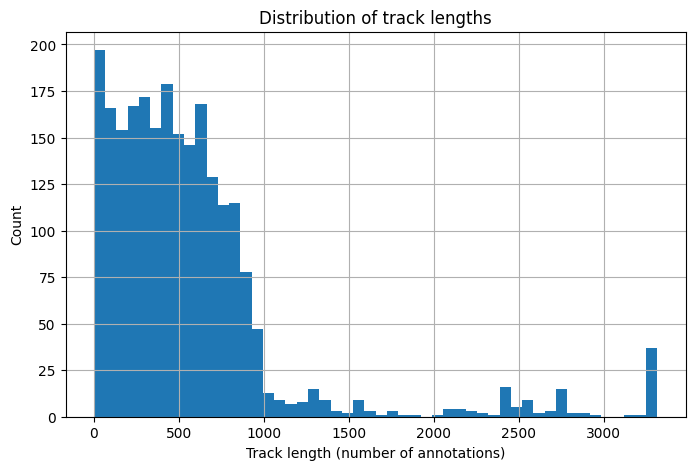

In [13]:
plt.figure(figsize=(8, 5))
track_df["num_annotations"].hist(bins=50)
plt.xlabel("Track length (number of annotations)")
plt.ylabel("Count")
plt.title("Distribution of track lengths")
plt.show()


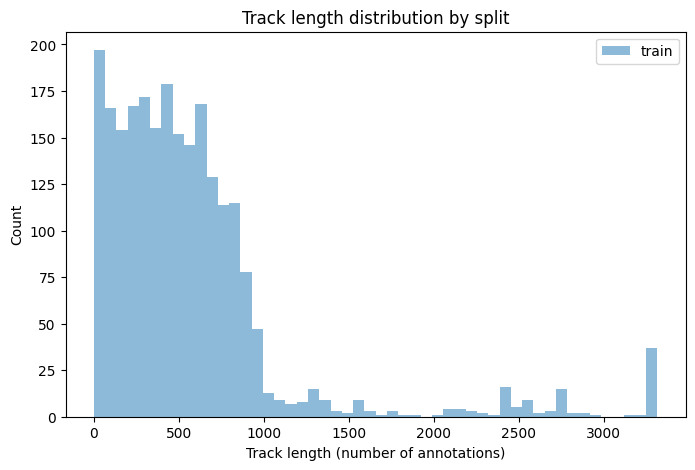

In [14]:
plt.figure(figsize=(8, 5))
for split_name, subset in track_df.groupby("split"):
    subset["num_annotations"].plot(kind="hist", bins=50, alpha=0.5, label=split_name)
plt.xlabel("Track length (number of annotations)")
plt.ylabel("Count")
plt.title("Track length distribution by split")
plt.legend()
plt.show()


$\text{coverage\_ratio} = \frac{\text{num\_annotations}}{\text{frame\_span}}$

$\text{frame\_span} = \text{end\_frame} - \text{start\_frame} + 1$

$\text{missing\_frames\_inside\_span} = \text{frame\_span} - \text{num\_annotations}$

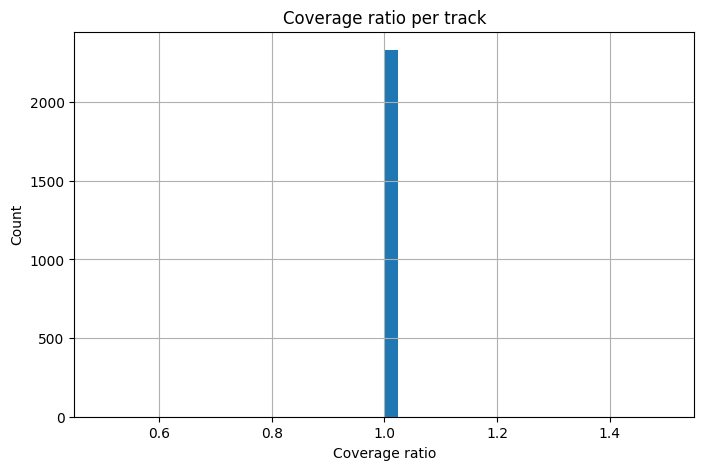

In [15]:
plt.figure(figsize=(8, 5))
track_df["coverage_ratio"].hist(bins=40)
plt.xlabel("Coverage ratio")
plt.ylabel("Count")
plt.title("Coverage ratio per track")
plt.show()


Great!

There is annotation in every frame, meaning no missing frames (saves us a loooot of time)

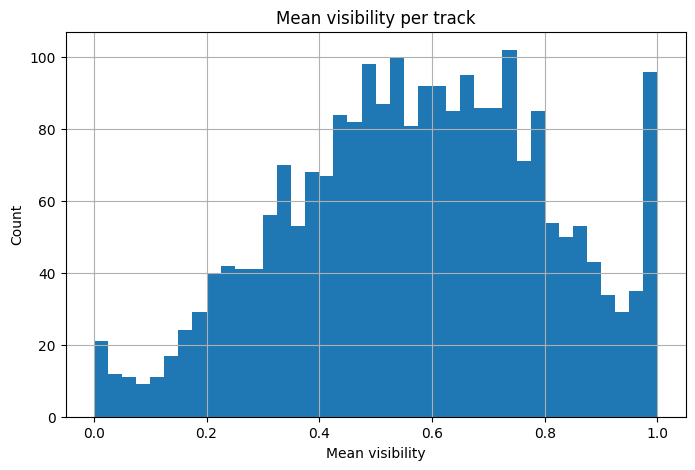

In [16]:
plt.figure(figsize=(8, 5))
track_df["mean_visibility"].dropna().hist(bins=40)
plt.xlabel("Mean visibility")
plt.ylabel("Count")
plt.title("Mean visibility per track")
plt.show()


Visually this looks close to normally distributed, that is good. To not spoil ourselves we should not look at the splits distribution themselves. That would be leaking ourselves!

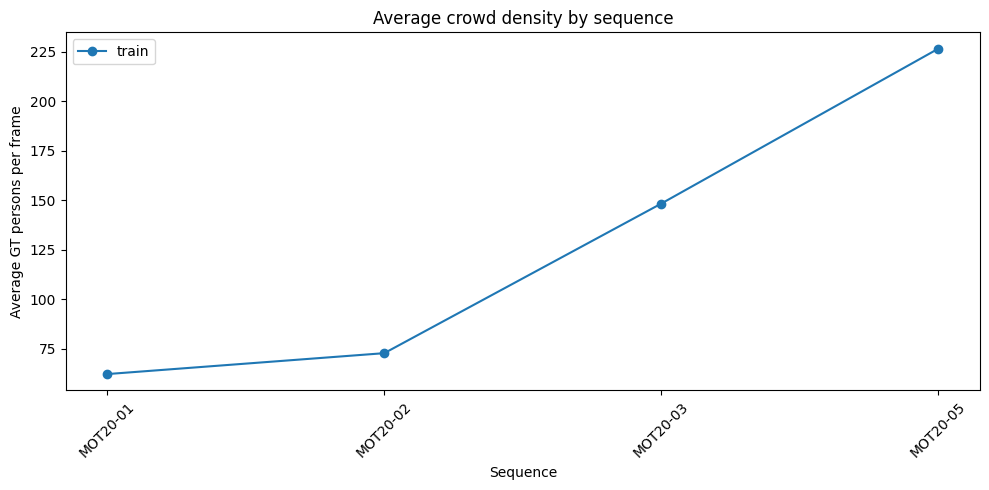

In [17]:
frame_density_plot = gt_frame_density.groupby(["split", "sequence"])["gt_person_count"].mean().reset_index()

plt.figure(figsize=(10, 5))
for split_name, subset in frame_density_plot.groupby("split"):
    plt.plot(subset["sequence"], subset["gt_person_count"], marker="o", label=split_name)
plt.xlabel("Sequence")
plt.ylabel("Average GT persons per frame")
plt.title("Average crowd density by sequence")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


$$
dx = \text{foot\_x}_t - \text{foot\_x}_{t-1}
$$
$$
dy = \text{foot\_y}_t - \text{foot\_y}_{t-1}<br
$$
$$
\text{step\_distance} = \sqrt{dx^2 + dy^2}
$$

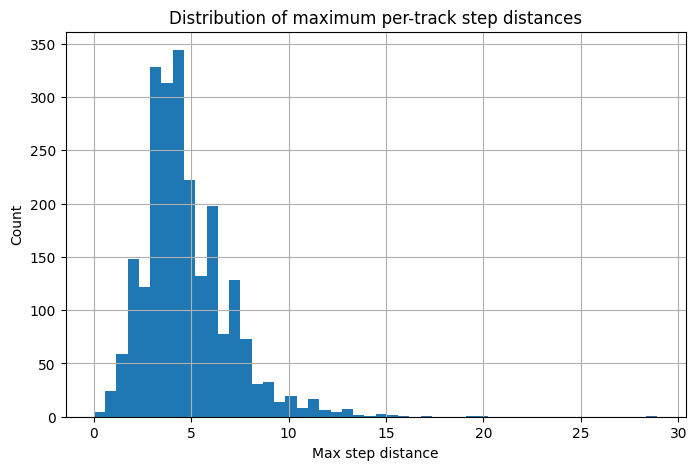

In [18]:
plt.figure(figsize=(8, 5))
track_motion_df["max_step_distance"].dropna().hist(bins=50)
plt.xlabel("Max step distance")
plt.ylabel("Count")
plt.title("Distribution of maximum per-track step distances")
plt.show()


This seems also normally distributed with some outliers.
I dont think this requires cleaning, as this is just a sanity check to see if it kinda makes sense. The really big or really small ones could be caused by the camera angle.

Importatnly this is of course pixel distance!

Sequence summary table

In [19]:
sequence_summary_df = (
    ann_df[ann_df["source"] == "gt"]
    .groupby(["dataset", "split", "sequence"], as_index=False)
    .agg(
        num_frames=("frame_id", "nunique"),
        num_annotations=("frame_id", "size"),
        num_tracks=("track_id", "nunique"),
        mean_visibility=("visibility", "mean"),
        mean_bbox_area=("bbox_area", "mean"),
    )
)

mean_people_per_frame = (
    gt_frame_density.groupby(["dataset", "split", "sequence"], as_index=False)["gt_person_count"]
    .mean()
    .rename(columns={"gt_person_count": "avg_people_per_frame"})
)

sequence_summary_df = sequence_summary_df.merge(
    mean_people_per_frame,
    on=["dataset", "split", "sequence"],
    how="left",
)

sequence_summary_df.sort_values(["split", "sequence"]).reset_index(drop=True)


,dataset,split,sequence,num_frames,num_annotations,num_tracks,mean_visibility,mean_bbox_area,avg_people_per_frame
0,MOT20,train,MOT20-01,429,26647,90,0.548752,19959.613240,62.114219
1,MOT20,train,MOT20-02,2782,202215,296,0.516074,19595.857459,72.686916
2,MOT20,train,MOT20-03,2405,356728,735,0.662282,4842.632266,148.327651
3,MOT20,train,MOT20-05,3315,751330,1211,0.533329,9404.816283,226.645551


#### Quick cleaning-oriented checks

In [20]:
print("Duplicate GT rows by sequence/frame/track:")
duplicate_gt_rows = ann_df[ann_df["source"] == "gt"].duplicated(
    subset=["dataset", "split", "sequence", "frame_id", "track_id"],
    keep=False,
)
print(int(duplicate_gt_rows.sum()))
print()

print("Invalid bbox rows (w <= 0 or h <= 0):")
invalid_bbox_rows = ann_df[(ann_df["w"] <= 0) | (ann_df["h"] <= 0)]
print(len(invalid_bbox_rows))
print()

print("Rows with footpoint outside image bounds:")
out_of_bounds_rows = ann_df[
    (ann_df["foot_x"] < 0)
    | (ann_df["foot_x"] > ann_df["image_width"])
    | (ann_df["foot_y"] < 0)
    | (ann_df["foot_y"] > ann_df["image_height"])
]
print(len(out_of_bounds_rows))


Duplicate GT rows by sequence/frame/track:
0

Invalid bbox rows (w <= 0 or h <= 0):
0

Rows with footpoint outside image bounds:
44031


The large number of rows with footprints outside of image bounds is quite worrieng (44031)
THis though could be because of MOT's annotation style.


I would not advocate for removing them entirely, we should first check if they are actually all far outside or not, the code for that follows:

In [21]:
gt_out_of_bounds_rows = ann_df[
    (ann_df["source"] == "gt") &
    (
        (ann_df["foot_x"] < 0)
        | (ann_df["foot_x"] > ann_df["image_width"])
        | (ann_df["foot_y"] < 0)
        | (ann_df["foot_y"] > ann_df["image_height"])
    )
].copy()

print(gt_out_of_bounds_rows.groupby(["split", "sequence"]).size().sort_values(ascending=False))

split  sequence
train  MOT20-05    25930
       MOT20-03    12835
       MOT20-02     4167
       MOT20-01     1099
dtype: int64


In [22]:
gt_out_of_bounds_rows["foot_x_excess_left"] = -gt_out_of_bounds_rows["foot_x"]
gt_out_of_bounds_rows["foot_x_excess_right"] = gt_out_of_bounds_rows["foot_x"] - gt_out_of_bounds_rows["image_width"]
gt_out_of_bounds_rows["foot_y_excess_bottom"] = gt_out_of_bounds_rows["foot_y"] - gt_out_of_bounds_rows["image_height"]

print(gt_out_of_bounds_rows[["foot_x", "foot_y", "image_width", "image_height"]].describe())
print(gt_out_of_bounds_rows[["foot_x_excess_left", "foot_x_excess_right", "foot_y_excess_bottom"]].describe())

             foot_x        foot_y   image_width  image_height
count  44031.000000  44031.000000  44031.000000  44031.000000
mean     678.909655   1022.700166   1545.601849   1021.700166
std      472.733287     90.891605    253.288536     90.891605
min        3.500000    881.000000   1173.000000    880.000000
25%      240.000000    881.000000   1173.000000    880.000000
50%      577.500000   1081.000000   1654.000000   1080.000000
75%     1051.000000   1081.000000   1654.000000   1080.000000
max     1906.000000   1081.000000   1920.000000   1080.000000
       foot_x_excess_left  foot_x_excess_right  foot_y_excess_bottom
count        44031.000000         44031.000000               44031.0
mean          -678.909655          -866.692194                   1.0
std            472.733287           476.362199                   0.0
min          -1906.000000         -1900.500000                   1.0
25%          -1051.000000         -1208.000000                   1.0
50%           -577.500000   

In [23]:
severe_margin = 20

severe_gt_out_of_bounds_rows = gt_out_of_bounds_rows[
    (gt_out_of_bounds_rows["foot_x"] < -severe_margin)
    | (gt_out_of_bounds_rows["foot_x"] > gt_out_of_bounds_rows["image_width"] + severe_margin)
    | (gt_out_of_bounds_rows["foot_y"] < -severe_margin)
    | (gt_out_of_bounds_rows["foot_y"] > gt_out_of_bounds_rows["image_height"] + severe_margin)
].copy()

print("Severe out-of-bounds GT rows:", len(severe_gt_out_of_bounds_rows))

severe_gt_out_of_bounds_rows[[
    "sequence", "track_id", "frame_id", "x", "y", "w", "h", "foot_x", "foot_y"
]].sort_values(["sequence", "track_id", "frame_id"]).reset_index(drop=True)

Severe out-of-bounds GT rows: 0


,sequence,track_id,frame_id,x,y,w,h,foot_x,foot_y


Ok so nothing is severely outside of the margin, that is very good!
I chose 20 to be not too scrict, as that can be simply traveling along the border but also not to lax, meaning that they are actually far outside.
This margin is of course in pixels!

## Dataset prep for training

Now because this is supposed to serve a baseline and we very much have to keep in mind that when we apply our model to the real time feed we have to enure that all the data that we train on can also be used during inference.<br>
The "most interesting" part of our application is the real time application, there we depend on a real time feed and an additional model that delivers the person tracking capabilities. <br>
Hence we may have more features available in an extensive training that we have in inference.

Time is also a very important consideration in inference on a live datastream. Heavy calculations slow down the process, and slowing down is not a luxury we can afford in out application


### Baseline feature pipeline

We prepare a deployment-aligned baseline dataset using only features that can realistically be derived later in test-time and live-stream settings from tracked pedestrian trajectories.

Chosen baseline feature set:

- `foot_x_norm`, `foot_y_norm`
- `dx_norm`, `dy_norm`
- `vx_norm`, `vy_norm`
- `speed_norm`
- `near_border_flag`

Additionally, we keep enough metadata and pixel-space coordinates to:

- reconstruct trajectories,
- overlay predicted vs real tracks on the image later,
- and debug predictions sequence-by-sequence and frame-by-frame.


In [24]:
def build_baseline_trajectory_df(
    ann_df: pd.DataFrame,
    border_margin_px: int = 5,
) -> pd.DataFrame:
    """
    Build a deployment-aligned per-frame trajectory table for the baseline model.

    One row = one GT pedestrian annotation at one frame.

    We keep:
    - normalized baseline features for training/inference
    - image metadata
    - pixel-space coordinates for later image overlay of predictions vs ground truth
    """
    gt = ann_df[ann_df["source"] == "gt"].copy()

    gt = gt.sort_values(
        ["dataset", "split", "sequence", "track_id", "frame_id"]
    ).reset_index(drop=True)

    # Basic time / image metadata
    gt["time_sec"] = gt["frame_id"] / gt["frame_rate"]
    gt["image_area"] = gt["image_width"] * gt["image_height"]

    # Normalized position features
    gt["foot_x_norm"] = gt["foot_x"] / gt["image_width"]
    gt["foot_y_norm"] = gt["foot_y"] / gt["image_height"]

    # Previous-step values per trajectory
    group_cols = ["dataset", "split", "sequence", "track_id"]
    gt["prev_frame_id"] = gt.groupby(group_cols)["frame_id"].shift(1)
    gt["prev_foot_x"] = gt.groupby(group_cols)["foot_x"].shift(1)
    gt["prev_foot_y"] = gt.groupby(group_cols)["foot_y"].shift(1)
    gt["prev_foot_x_norm"] = gt.groupby(group_cols)["foot_x_norm"].shift(1)
    gt["prev_foot_y_norm"] = gt.groupby(group_cols)["foot_y_norm"].shift(1)

    # Temporal gap
    gt["frame_gap"] = gt["frame_id"] - gt["prev_frame_id"]
    gt["dt_sec"] = gt["frame_gap"] / gt["frame_rate"]

    # Displacements in pixel space
    gt["dx"] = gt["foot_x"] - gt["prev_foot_x"]
    gt["dy"] = gt["foot_y"] - gt["prev_foot_y"]

    # Displacements in normalized image space
    gt["dx_norm"] = gt["foot_x_norm"] - gt["prev_foot_x_norm"]
    gt["dy_norm"] = gt["foot_y_norm"] - gt["prev_foot_y_norm"]

    # Velocities in normalized units per second
    gt["vx_norm"] = gt["dx_norm"] / gt["dt_sec"]
    gt["vy_norm"] = gt["dy_norm"] / gt["dt_sec"]
    gt["speed_norm"] = np.sqrt(gt["vx_norm"] ** 2 + gt["vy_norm"] ** 2)

    # Border flags in pixel space
    gt["near_left_border"] = gt["foot_x"] <= border_margin_px
    gt["near_right_border"] = gt["foot_x"] >= (gt["image_width"] - border_margin_px)
    gt["near_top_border"] = gt["foot_y"] <= border_margin_px
    gt["near_bottom_border"] = gt["foot_y"] >= (gt["image_height"] - border_margin_px)
    gt["near_border_flag"] = (
        gt["near_left_border"]
        | gt["near_right_border"]
        | gt["near_top_border"]
        | gt["near_bottom_border"]
    ).astype(int)

    # Keep only rows where motion features are actually defined
    # (first observation of each track has no previous frame)
    gt = gt[gt["prev_frame_id"].notna()].copy()
    gt = gt[gt["dt_sec"] > 0].copy()

    # Optional safety cleanup for infinities introduced by division
    numeric_cols = [
        "dx", "dy", "dx_norm", "dy_norm",
        "vx_norm", "vy_norm", "speed_norm",
        "frame_gap", "dt_sec"
    ]
    gt[numeric_cols] = gt[numeric_cols].replace([np.inf, -np.inf], np.nan)
    gt = gt.dropna(subset=[
        "foot_x_norm", "foot_y_norm",
        "dx_norm", "dy_norm",
        "vx_norm", "vy_norm", "speed_norm"
    ]).copy()

    # Ordered export schema
    export_columns = [
        # identity / indexing
        "dataset", "split", "sequence", "track_id", "frame_id", "time_sec",
        # image metadata
        "image_path", "image_width", "image_height", "image_area", "frame_rate",
        # pixel-space real position for later overlay
        "foot_x", "foot_y",
        # raw bbox kept for debugging / optional overlay extensions
        "x", "y", "w", "h", "bbox_area", "visibility",
        # previous step metadata
        "prev_frame_id", "frame_gap", "dt_sec",
        # baseline model features
        "foot_x_norm", "foot_y_norm",
        "dx_norm", "dy_norm",
        "vx_norm", "vy_norm",
        "speed_norm",
        "near_border_flag",
        # useful optional diagnostics
        "dx", "dy",
        "near_left_border", "near_right_border", "near_top_border", "near_bottom_border",
    ]

    baseline_df = gt[export_columns].sort_values(
        ["split", "sequence", "track_id", "frame_id"]
    ).reset_index(drop=True)

    return baseline_df


In [25]:
baseline_trainval_input_ann_df = pd.concat([
    train_ann_df.assign(split="train"),
    val_ann_df.assign(split="val"),
], ignore_index=True)

baseline_df = build_baseline_trajectory_df(baseline_trainval_input_ann_df, border_margin_px=20)

print("baseline_df shape:", baseline_df.shape)
print()
print("Split counts in GT-based baseline export:")
print(baseline_df["split"].value_counts(dropna=False))
print()
print("Original annotation counts by split/source:")
print(
    pd.concat([
        train_ann_df.assign(project_split="train"),
        val_ann_df.assign(project_split="val"),
        test_ann_df.assign(project_split="test"),
    ], ignore_index=True)
    .groupby(["project_split", "source"])
    .size()
)

baseline_df.head()

baseline_df shape: (1334588, 36)

Split counts in GT-based baseline export:
split
val      750119
train    584469
Name: count, dtype: int64

Original annotation counts by split/source:
project_split  source
test           det       361798
train          det       279794
               gt        585590
val            det       381349
               gt        751330
dtype: int64


,dataset,split,sequence,track_id,frame_id,time_sec,image_path,image_width,image_height,image_area,...,vx_norm,vy_norm,speed_norm,near_border_flag,dx,dy,near_left_border,near_right_border,near_top_border,near_bottom_border
0,MOT20,train,MOT20-01,1,2,0.08,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,2073600,...,0.026042,-0.023148,0.034843,1,2.0,-1.0,False,False,False,True
1,MOT20,train,MOT20-01,1,3,0.12,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,2073600,...,0.026042,0.000000,0.026042,1,2.0,0.0,False,False,False,True
2,MOT20,train,MOT20-01,1,4,0.16,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,2073600,...,0.039062,0.000000,0.039062,1,3.0,0.0,False,False,False,True
3,MOT20,train,MOT20-01,1,5,0.20,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,2073600,...,0.026042,0.000000,0.026042,1,2.0,0.0,False,False,False,True
4,MOT20,train,MOT20-01,1,6,0.24,c:\-=- Main files -=-\UM\Year 2\Project 2.2\Gi...,1920,1080,2073600,...,0.039062,0.000000,0.039062,1,3.0,0.0,False,False,False,True


We export one baseline trajectory table per split:

- train
- val
- test

Each exported file contains both:

- the actual baseline model inputs,
- the pixel/image metadata required for later visualization and overlay.


In [26]:
train_baseline_df = baseline_df[baseline_df["split"] == "train"].copy()
val_baseline_df = baseline_df[baseline_df["split"] == "val"].copy()

# MOT20 official test usually has no GT-based trajectory labels available here.
# We still create an empty dataframe with the same schema so the export structure stays consistent.
test_baseline_df = pd.DataFrame(columns=baseline_df.columns)

print("train baseline shape:", train_baseline_df.shape)
print("val baseline shape:", val_baseline_df.shape)
print("test baseline shape:", test_baseline_df.shape)
print()
print("Note: test baseline is empty because this export is GT-based and MOT20 test has no GT trajectory labels here.")


train baseline shape: (584469, 36)
val baseline shape: (750119, 36)
test baseline shape: (0, 36)

Note: test baseline is empty because this export is GT-based and MOT20 test has no GT trajectory labels here.


Export structure

We export to:

../Data/prepared_baseline/{train,val,test}/

Inside each split folder we store:

- baseline_trajectory.csv --> the prepared per-frame baseline data
- README.txt --> a small description of the export (A LLM gave me this idea, we might have to credit that!)

This structure keeps train/val/test clearly separated and makes later loading easy.


In [27]:
def export_baseline_split_data(
    split_df: pd.DataFrame,
    split_name: str,
    base_output_dir: Path,
) -> None:
    split_dir = base_output_dir / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    csv_path = split_dir / "baseline_trajectory.csv"
    readme_path = split_dir / "README.txt"

    split_df.to_csv(csv_path, index=False)

    feature_columns = [
        "foot_x_norm", "foot_y_norm",
        "dx_norm", "dy_norm",
        "vx_norm", "vy_norm",
        "speed_norm",
        "near_border_flag",
    ]

    if len(split_df) == 0 and split_name == "test":
        readme_text = "\n".join([
            f"Split: {split_name}",
            "",
            "This CSV is intentionally empty.",
            "Reason: the current baseline export is GT-based, but the official MOT20",
            "test split does not provide GT trajectory annotations here for supervised export.",
            "",
            "Use cases:",
            "- train on the train export",
            "- validate on the val export",
            "- use the test split later in runtime/inference mode",
            "- compare predictions to GT only where labels are actually available",
        ])
    else:
        readme_text = "\n".join([
            f"Split: {split_name}",
            "",
            "This file contains the deployment-aligned baseline trajectory data.",
            "One row corresponds to one GT pedestrian track observation at one frame,",
            "excluding the first observation of each track because motion features",
            "require a previous frame.",
            "",
            "Core baseline features:",
            *[f"- {col}" for col in feature_columns],
            "",
            "Additional metadata kept for evaluation and overlay:",
            "- dataset, split, sequence, track_id, frame_id, time_sec",
            "- image_path, image_width, image_height, frame_rate",
            "- foot_x, foot_y (pixel-space ground-truth footpoint)",
            "- x, y, w, h, bbox_area, visibility",
            "",
            "The pixel-space columns are intentionally retained so predicted vs real",
            "tracks can later be overlaid back onto the original image frames.",
        ])

    readme_path.write_text(readme_text, encoding="utf-8")

In [28]:
output_root = project_root / "data" / "prepared_baseline"
output_root.mkdir(parents=True, exist_ok=True)

export_baseline_split_data(train_baseline_df, "train", output_root)
export_baseline_split_data(val_baseline_df, "val", output_root)
export_baseline_split_data(test_baseline_df, "test", output_root)

print("Exported baseline data to", output_root)


Exported baseline data to c:\-=- Main files -=-\UM\Year 2\Project 2.2\Git\project_2-2_25-26_dsai_group-12\Data\prepared_baseline


export sanity checks

In [29]:
for split_name in ["train", "val", "test"]:
    csv_path = output_root / split_name / "baseline_trajectory.csv"
    print(split_name, csv_path.exists(), csv_path)

print()
print("Exported row counts:")
for split_name in ["train", "val", "test"]:
    csv_path = output_root / split_name / "baseline_trajectory.csv"
    exported_df = pd.read_csv(csv_path)
    print(split_name, exported_df.shape)

print()
print("Interpretation:")
print("train and val should contain GT-based trajectory rows, test should be empty")

train True c:\-=- Main files -=-\UM\Year 2\Project 2.2\Git\project_2-2_25-26_dsai_group-12\Data\prepared_baseline\train\baseline_trajectory.csv
val True c:\-=- Main files -=-\UM\Year 2\Project 2.2\Git\project_2-2_25-26_dsai_group-12\Data\prepared_baseline\val\baseline_trajectory.csv
test True c:\-=- Main files -=-\UM\Year 2\Project 2.2\Git\project_2-2_25-26_dsai_group-12\Data\prepared_baseline\test\baseline_trajectory.csv

Exported row counts:
train (584469, 36)
val (750119, 36)
test (0, 36)

Interpretation:
train and val should contain GT-based trajectory rows, test should be empty


Recommended for image overlay @frontend

1. run inference on the normalized baseline features,
2. obtain predicted normalized positions,
3. convert them back to pixel coordinates using image width/height,
4. draw both the predicted and real footpoints/paths on the image referenced by image_path.
